In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [2]:
df = pd.read_csv("E:\python projects\Behaviour-Based Analysis and Suggestion Children\special_children_behavior_dataset_20k.csv")
print(df.shape)
df.head()


(20000, 11)


,Child_ID,Observation_Time,Attention_Level,Mood_Score,Stress_Level,Interaction_Level,Task_Engagement,Trigger_Noise,Trigger_Social,Routine_Change,Emotional_State
0,72,2026-01-01 08:00:00,2,2,4,4,4,1,0,1,Stressed
1,620,2026-01-01 08:01:00,5,5,1,4,5,0,0,0,Happy
2,524,2026-01-01 08:02:00,3,4,3,1,3,0,1,0,Happy
3,352,2026-01-01 08:03:00,4,3,2,4,3,0,0,0,Happy
4,347,2026-01-01 08:04:00,4,4,2,3,4,0,0,0,Happy


In [3]:
df.info()
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Child_ID           20000 non-null  int64 
 1   Observation_Time   20000 non-null  object
 2   Attention_Level    20000 non-null  int64 
 3   Mood_Score         20000 non-null  int64 
 4   Stress_Level       20000 non-null  int64 
 5   Interaction_Level  20000 non-null  int64 
 6   Task_Engagement    20000 non-null  int64 
 7   Trigger_Noise      20000 non-null  int64 
 8   Trigger_Social     20000 non-null  int64 
 9   Routine_Change     20000 non-null  int64 
 10  Emotional_State    20000 non-null  object
dtypes: int64(9), object(2)
memory usage: 1.7+ MB


Child_ID             0
Observation_Time     0
Attention_Level      0
Mood_Score           0
Stress_Level         0
Interaction_Level    0
Task_Engagement      0
Trigger_Noise        0
Trigger_Social       0
Routine_Change       0
Emotional_State      0
dtype: int64

In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Child_ID,20000.0,NaN,NaN,NaN,397.69195,230.561113,1.0,198.0,397.0,596.0,800.0
Observation_Time,20000,20000,2026-01-01 08:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Attention_Level,20000.0,NaN,NaN,NaN,3.5433,0.823626,1.0,3.0,4.0,4.0,5.0
Mood_Score,20000.0,NaN,NaN,NaN,3.4276,0.884023,1.0,3.0,3.0,4.0,5.0
Stress_Level,20000.0,NaN,NaN,NaN,2.647,0.858037,1.0,2.0,3.0,3.0,5.0
Interaction_Level,20000.0,NaN,NaN,NaN,3.3255,0.830352,1.0,3.0,3.0,4.0,5.0
Task_Engagement,20000.0,NaN,NaN,NaN,3.46885,0.809545,1.0,3.0,3.0,4.0,5.0
Trigger_Noise,20000.0,NaN,NaN,NaN,0.2852,0.451521,0.0,0.0,0.0,1.0,1.0
Trigger_Social,20000.0,NaN,NaN,NaN,0.22025,0.414426,0.0,0.0,0.0,0.0,1.0
Routine_Change,20000.0,NaN,NaN,NaN,0.1788,0.383194,0.0,0.0,0.0,0.0,1.0


In [5]:
df.isnull().sum()

Child_ID             0
Observation_Time     0
Attention_Level      0
Mood_Score           0
Stress_Level         0
Interaction_Level    0
Task_Engagement      0
Trigger_Noise        0
Trigger_Social       0
Routine_Change       0
Emotional_State      0
dtype: int64

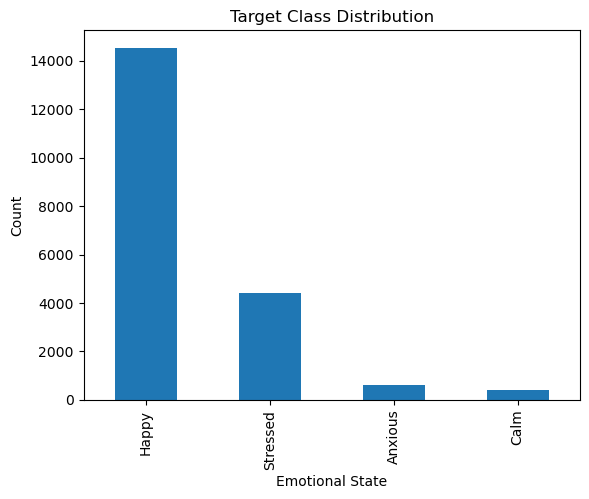

Happy       14539
Stressed     4410
Anxious       632
Calm          419
Name: Emotional_State, dtype: int64

In [6]:
target_col = "Emotional_State"
vc = df[target_col].value_counts()

plt.figure()
vc.plot(kind="bar")
plt.title("Target Class Distribution")
plt.xlabel("Emotional State")
plt.ylabel("Count")
plt.show()

vc


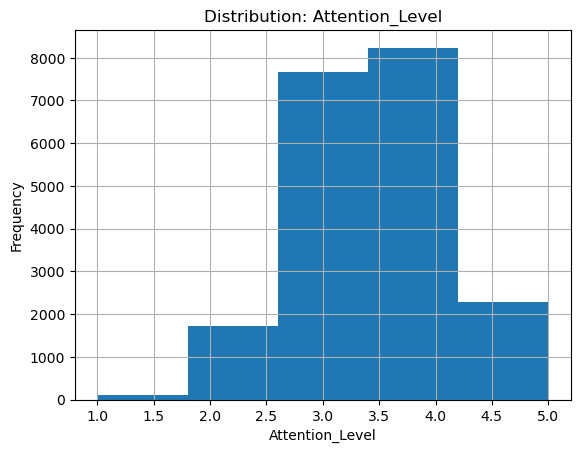

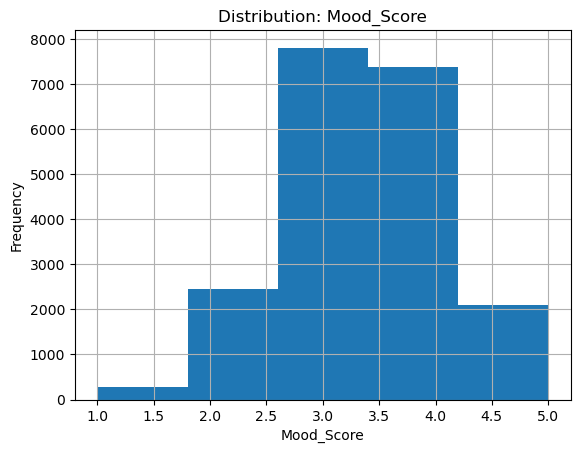

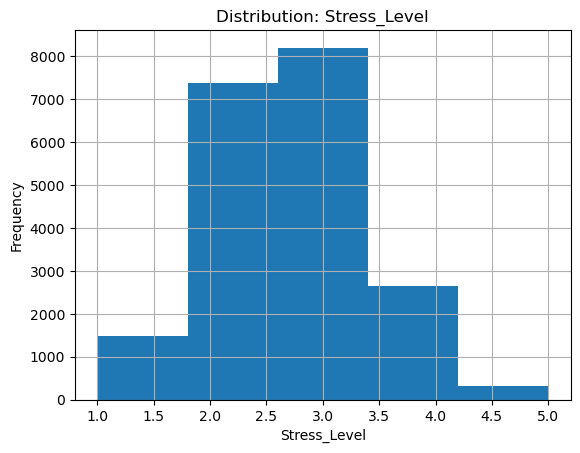

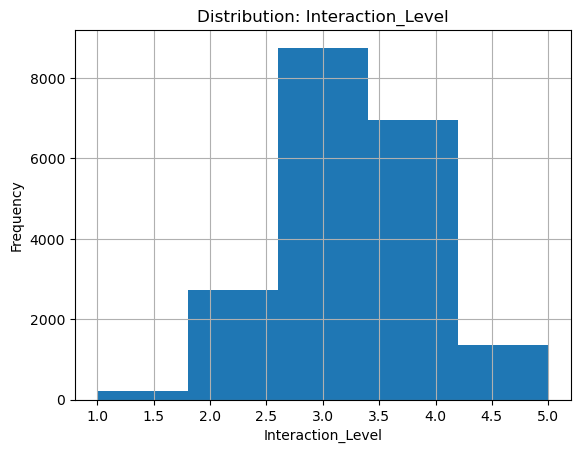

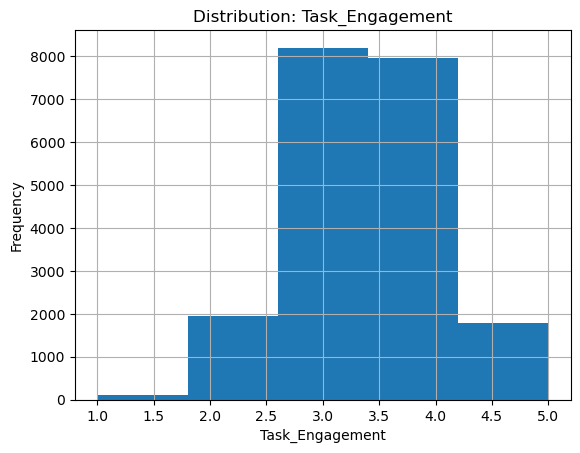

In [7]:
num_cols = ["Attention_Level","Mood_Score","Stress_Level","Interaction_Level","Task_Engagement"]

for c in num_cols:
    plt.figure()
    df[c].hist(bins=5)
    plt.title(f"Distribution: {c}")
    plt.xlabel(c)
    plt.ylabel("Frequency")
    plt.show()


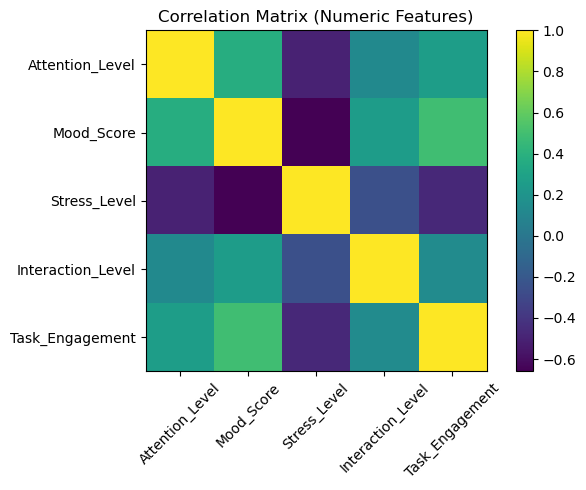

,Attention_Level,Mood_Score,Stress_Level,Interaction_Level,Task_Engagement
Attention_Level,1.000000,0.371579,-0.499833,0.129713,0.263561
Mood_Score,0.371579,1.000000,-0.659480,0.258668,0.490511
Stress_Level,-0.499833,-0.659480,1.000000,-0.253354,-0.466028
Interaction_Level,0.129713,0.258668,-0.253354,1.000000,0.141242
Task_Engagement,0.263561,0.490511,-0.466028,0.141242,1.000000


In [8]:
corr = df[num_cols].corr()

plt.figure(figsize=(7,5))
plt.imshow(corr, interpolation="nearest")
plt.title("Correlation Matrix (Numeric Features)")
plt.xticks(range(len(num_cols)), num_cols, rotation=45)
plt.yticks(range(len(num_cols)), num_cols)
plt.colorbar()
plt.tight_layout()
plt.show()

corr


In [9]:
df["Observation_Time"] = pd.to_datetime(df["Observation_Time"], errors="coerce")

df["obs_hour"] = df["Observation_Time"].dt.hour
df["obs_dayofweek"] = df["Observation_Time"].dt.dayofweek

# optional: drop raw time column (ML doesn't need it)
df = df.drop(columns=["Observation_Time"])

df.head()


,Child_ID,Attention_Level,Mood_Score,Stress_Level,Interaction_Level,Task_Engagement,Trigger_Noise,Trigger_Social,Routine_Change,Emotional_State,obs_hour,obs_dayofweek
0,72,2,2,4,4,4,1,0,1,Stressed,8,3
1,620,5,5,1,4,5,0,0,0,Happy,8,3
2,524,3,4,3,1,3,0,1,0,Happy,8,3
3,352,4,3,2,4,3,0,0,0,Happy,8,3
4,347,4,4,2,3,4,0,0,0,Happy,8,3


In [10]:
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((16000, 11), (4000, 11))

In [11]:
numeric_features = ["Attention_Level","Mood_Score","Stress_Level","Interaction_Level","Task_Engagement",
                    "Trigger_Noise","Trigger_Social","Routine_Change","obs_hour","obs_dayofweek"]

categorical_features = ["Child_ID"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)


In [12]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "SVM_RBF": SVC(kernel="rbf", probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42)
}


In [13]:
results = []

best_name = None
best_f1 = -1
best_pipeline = None

for name, clf in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess),
                          ("model", clf)])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="weighted")

    results.append((name, acc, f1))
    
    print("="*60)
    print(name)
    print("Accuracy:", round(acc, 4))
    print("F1-score :", round(f1, 4))
    
    if f1 > best_f1:
        best_f1 = f1
        best_name = name
        best_pipeline = pipe

results_df = pd.DataFrame(results, columns=["Model","Accuracy","F1_weighted"]).sort_values(by="F1_weighted", ascending=False)
results_df


LogisticRegression
Accuracy: 0.898
F1-score : 0.8752
SVM_RBF
Accuracy: 0.9323
F1-score : 0.9168
KNN
Accuracy: 0.9083
F1-score : 0.8895
DecisionTree
Accuracy: 0.883
F1-score : 0.8816
RandomForest
Accuracy: 0.928
F1-score : 0.9096


,Model,Accuracy,F1_weighted
1,SVM_RBF,0.93225,0.916758
4,RandomForest,0.92800,0.909607
2,KNN,0.90825,0.889453
3,DecisionTree,0.88300,0.881646
0,LogisticRegression,0.89800,0.875182


✅ Best Model: SVM_RBF | Best F1: 0.9168

Classification Report:

              precision    recall  f1-score   support

     Anxious       0.82      0.29      0.43       126
        Calm       0.00      0.00      0.00        84
       Happy       0.94      0.99      0.96      2908
    Stressed       0.92      0.92      0.92       882

    accuracy                           0.93      4000
   macro avg       0.67      0.55      0.58      4000
weighted avg       0.91      0.93      0.92      4000



C:\Users\ADMIN\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ADMIN\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ADMIN\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

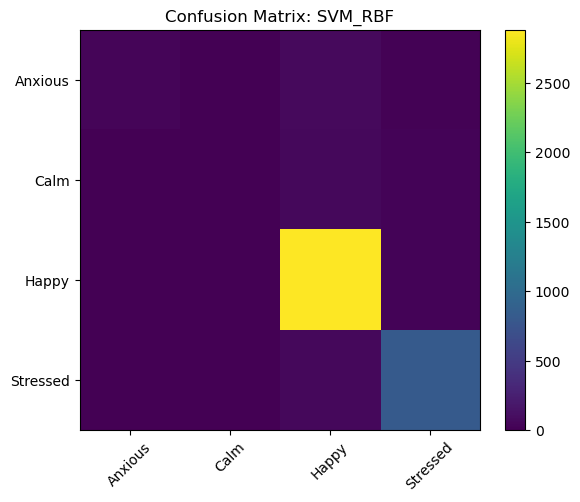

array([[  37,    0,   69,   20],
       [   1,    0,   58,   25],
       [   3,    0, 2881,   24],
       [   4,    0,   67,  811]], dtype=int64)

In [15]:
print("✅ Best Model:", best_name, "| Best F1:", round(best_f1, 4))

best_preds = best_pipeline.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, best_preds))

cm = confusion_matrix(y_test, best_preds, labels=sorted(y.unique()))

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix: {best_name}")
plt.xticks(range(len(sorted(y.unique()))), sorted(y.unique()), rotation=45)
plt.yticks(range(len(sorted(y.unique()))), sorted(y.unique()))
plt.colorbar()
plt.tight_layout()
plt.show()

cm


In [16]:
joblib.dump(best_pipeline, "best_emotion_model.pkl")
print("✅ Saved model to: best_emotion_model.pkl")


✅ Saved model to: best_emotion_model.pkl
